In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report
from sklearn.metrics.pairwise import cosine_similarity
import json, warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


In [44]:
# Load the cleaned ATS pairs dataset
df = pd.read_csv('clear_resumeJD_pairs.csv')
print(f'Loaded: {len(df)} pairs')
print(f'\nLabel distribution:')
print(df['match_label'].value_counts())
print(f'\nScore range: {df["match_score"].min():.2f} – {df["match_score"].max():.2f}')
df.head(3)


Loaded: 288 pairs

Label distribution:
match_label
medium    118
low        97
high       73
Name: count, dtype: int64

Score range: 0.45 – 0.98


,resume_text,job_description,match_score,match_label,match_label_lower,resume_len,jd_len
0,Data Analyst with 8 years of experience in Cyb...,Looking for a Data Analyst at a growing compan...,0.91,high,high,21,20
1,Frontend Developer with 7 years of experience ...,Looking for a Frontend Developer at a growing ...,0.72,medium,medium,21,20
2,Java Developer with 2 years of experience in N...,Looking for a Java Developer at a growing comp...,0.91,high,high,21,20


In [45]:
#Train / Val / Test Split
#Stratify by match_label so each split has balanced high/medium/low

train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['match_label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['match_label']
)

print(f'Train:      {len(train_df)} pairs')
print(f'Validation: {len(val_df)} pairs')
print(f'Test:       {len(test_df)} pairs')
print()

# Verify each split has all 3 labels
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name} label dist: {split["match_label"].value_counts().to_dict()}')


Train:      201 pairs
Validation: 43 pairs
Test:       44 pairs

Train label dist: {'medium': 82, 'low': 68, 'high': 51}
Val label dist: {'medium': 18, 'low': 14, 'high': 11}
Test label dist: {'medium': 18, 'low': 15, 'high': 11}


In [46]:
#Convert to InputExample format — sentence-transformers expects this
#text1 = resume, text2 = job description, label = match_score (float 0-1)

train_examples = [
    InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in train_df.iterrows()
]

val_examples = [
    InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in val_df.iterrows()
]

print(f'Train examples: {len(train_examples)}')
print(f'Val examples:   {len(val_examples)}')
print(f'\nSample InputExample:')
print(f'  text1 (resume): {train_examples[0].texts[0][:80]}...')
print(f'  text2 (JD):     {train_examples[0].texts[1][:80]}...')
print(f'  label:          {train_examples[0].label}')


Train examples: 201
Val examples:   43

Sample InputExample:
  text1 (resume): Data Analyst with 5 years of experience in AWS, TensorFlow, Pandas and FastAPI. ...
  text2 (JD):     Looking for a Data Analyst at a growing company. Required skills: AWS, TensorFlo...
  label:          0.54


In [47]:
#Base Model Baseline
print('Loading base BERT model...')
base_model = SentenceTransformer('all-mpnet-base-v2')
print('Loaded.')


Loading base BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded.


In [48]:
# Evaluate base model on test set BEFORE fine-tuning
# This is our baseline, fine-tuning should beat this
print('Evaluating base model on test set...')

base_preds = []
for _, row in test_df.iterrows():
    emb1 = base_model.encode(row['resume_text'])
    emb2 = base_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]
    base_preds.append(float(sim))

base_mae  = mean_absolute_error(test_df['match_score'], base_preds)
base_rmse = np.sqrt(mean_squared_error(test_df['match_score'], base_preds))

print(f'\nBase Model — Test Set Performance')
print(f'  MAE:  {base_mae:.4f}')
print(f'  RMSE: {base_rmse:.4f}')
print()
print('Goal: fine-tuning should reduce MAE below this number.')

Evaluating base model on test set...

Base Model — Test Set Performance
  MAE:  0.1465
  RMSE: 0.1752

Goal: fine-tuning should reduce MAE below this number.


In [49]:
#Fine-Tune BERT

# Fresh model instance for fine-tuning (don't reuse base_model)
model = SentenceTransformer('all-mpnet-base-v2')

# DataLoader, shuffles training data each epoch
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# CosineSimilarityLoss: trains the model so that
# cosine_similarity(embed(resume), embed(jd)) ≈ match_score
train_loss = losses.CosineSimilarityLoss(model)

# Evaluator runs on val set after each evaluation_steps
evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples, name='ats-val'
)

print('Training setup ready.')
print(f'  Batch size: 32   ')
print(f'  Train pairs:  {len(train_examples)}')
print(f'  Steps/epoch:  {len(train_dataloader)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training setup ready.
  Batch size: 32   
  Train pairs:  201
  Steps/epoch:  13


In [50]:
# Fine-tune
# epochs=10 is reasonable for 200-250 training pairs
# warmup_steps = 10% of total steps

total_steps   = len(train_dataloader) * 10
warmup_steps  = int(total_steps * 0.1)

print(f'Total steps:  {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'\nStarting fine-tuning...\n')

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=10,
    evaluation_steps=len(train_dataloader),   # evaluate once per epoch
    warmup_steps=warmup_steps,
    output_path='models/finetuned-bert',
    save_best_model=True,
    show_progress_bar=True
)

print('\nFine-tuning complete!')

Total steps:  130
Warmup steps: 13

Starting fine-tuning...



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Ats-val Pearson Cosine,Ats-val Spearman Cosine
13,No log,No log,-0.109268,-0.054550
26,No log,No log,-0.083327,-0.085981
39,No log,No log,-0.089934,-0.088021
52,No log,No log,-0.087924,-0.064750
65,No log,No log,-0.040944,-0.040270
78,No log,No log,-0.028099,-0.001284
91,No log,No log,-0.020913,0.043142
104,No log,No log,-0.024979,0.032337
117,No log,No log,-0.026025,0.039968
130,No log,No log,-0.026111,0.033848


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning complete!


In [51]:
#Evaluate Fine-Tuned Model

finetuned_model = SentenceTransformer('models/finetuned-bert')
print('Fine-tuned model loaded.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded.


In [52]:
ft_preds = []
for _, row in test_df.iterrows():
    emb1 = finetuned_model.encode(row['resume_text'])
    emb2 = finetuned_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]
    ft_preds.append(float(sim))

ft_mae  = mean_absolute_error(test_df['match_score'], ft_preds)
ft_rmse = np.sqrt(mean_squared_error(test_df['match_score'], ft_preds))

print(f'\nFine-tuned Model — Test Set Performance')
print(f'  MAE:  {ft_mae:.4f}')
print(f'  RMSE: {ft_rmse:.4f}')


Fine-tuned Model — Test Set Performance
  MAE:  0.1568
  RMSE: 0.1850


In [53]:
# Side-by-side comparison
print('=' * 50)
print('MODEL COMPARISON')
print('=' * 50)
print(f'  Base MAE:         {base_mae:.4f}')
print(f'  Fine-tuned MAE:   {ft_mae:.4f}')
print(f'  Improvement:      {(base_mae - ft_mae)/base_mae*100:.1f}%')
print('=' * 50)

MODEL COMPARISON
  Base MAE:         0.1465
  Fine-tuned MAE:   0.1568
  Improvement:      -7.1%


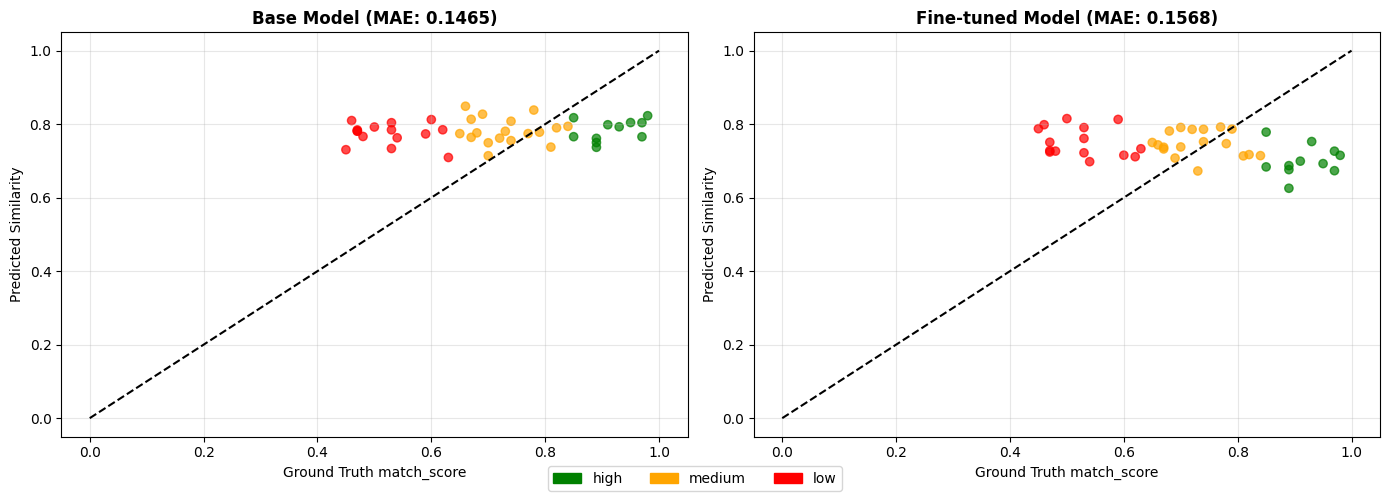

In [54]:
# Scatter plots: base vs fine-tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = test_df['match_label'].map({'low':'red','medium':'orange','high':'green'})

for ax, preds, title, mae in [
    (axes[0], base_preds, 'Base Model', base_mae),
    (axes[1], ft_preds,   'Fine-tuned Model', ft_mae),
]:
    ax.scatter(test_df['match_score'], preds, c=colors, alpha=0.7)
    ax.plot([0,1],[0,1],'k--', label='Perfect')
    ax.set_xlabel('Ground Truth match_score')
    ax.set_ylabel('Predicted Similarity')
    ax.set_title(f'{title} (MAE: {mae:.4f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color='green', label='high'),
    Patch(color='orange', label='medium'),
    Patch(color='red', label='low'),
], loc='lower center', ncol=3)
plt.tight_layout()
plt.show()

In [55]:
metadata = {
    'base_model':       'all-mpnet-base-v2',
    'dataset':          'merged_dataset_clean.csv',
    'total_pairs':      len(df),
    'train_pairs':      len(train_df),
    'val_pairs':        len(val_df),
    'test_pairs':       len(test_df),
    'epochs':           10,
    'batch_size':       16,
    'base_mae':         round(float(base_mae), 4),
    'finetuned_mae':    round(float(ft_mae), 4),
    'improvement_pct':  round((base_mae - ft_mae) / base_mae * 100, 2),
}

with open('models/finetuned-bert/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: models/finetuned-bert/')
print(json.dumps(metadata, indent=2))

Saved: models/finetuned-bert/
{
  "base_model": "all-mpnet-base-v2",
  "dataset": "merged_dataset_clean.csv",
  "total_pairs": 288,
  "train_pairs": 201,
  "val_pairs": 43,
  "test_pairs": 44,
  "epochs": 10,
  "batch_size": 16,
  "base_mae": 0.1465,
  "finetuned_mae": 0.1568,
  "improvement_pct": -7.05
}


In [56]:
#Production Pipeline Test

def score_resume_against_jd(resume_text, jd_text, model):

    emb_resume = model.encode(resume_text, convert_to_numpy=True)
    emb_jd     = model.encode(jd_text,     convert_to_numpy=True)
    score      = cosine_similarity([emb_resume], [emb_jd])[0][0]
    return float(score)


# Test with realistic cases
test_cases = [
    {
        'label':  'HIGH match expected',
        'resume': 'Senior Python developer with 6 years experience. Built REST APIs using FastAPI and Django. Proficient in PostgreSQL, Docker, and AWS deployment.',
        'jd':     'We need a Python backend engineer with FastAPI or Django experience. Must know SQL databases and cloud deployment.',
    },
    {
        'label':  'MEDIUM match expected',
        'resume': 'Frontend developer with 3 years React and TypeScript experience. Some Node.js and Express for small APIs.',
        'jd':     'Full stack engineer needed. React frontend required, strong Python backend preferred. 4+ years experience.',
    },
    {
        'label':  'LOW match expected',
        'resume': 'Executive Chef with 12 years experience in fine dining. Expert in French cuisine, menu planning, and kitchen management.',
        'jd':     'Data Scientist with Python, machine learning, and SQL experience required.',
    },
]

print('Production Pipeline Test')
print('=' * 60)
for case in test_cases:
    score = score_resume_against_jd(case['resume'], case['jd'], finetuned_model)
    label = 'HIGH' if score > 0.70 else 'MEDIUM' if score > 0.45 else 'LOW'
    print(f"\n{case['label']}")
    print(f"  Predicted score: {score:.4f}  →  {label}")


Production Pipeline Test

HIGH match expected
  Predicted score: 0.7064  →  HIGH

MEDIUM match expected
  Predicted score: 0.8343  →  HIGH

LOW match expected
  Predicted score: 0.4013  →  LOW
